# Esercizi di Laboratorio – Lezioni 1, 2 e 3
**Corso: Trattamento di Dati Multimediali**

Questo notebook raccoglie esercizi pratici che coprono i contenuti delle prime tre lezioni di laboratorio:
- **Lezione 1** – Manipolazione di immagini con Python (Pillow)
- **Lezione 2** – Analisi dell'Istogramma e dei Canali Colore
- **Lezione 3** – RGB e HSV: Rappresentazione e Percezione del Colore

Per ogni esercizio è indicata una traccia testuale seguita da una cella di codice da completare.  
Le celle marcate `# SOLUZIONE` contengono la soluzione completa: prova a risolvere l'esercizio **prima** di consultarle!


## Setup – Librerie e immagine di lavoro

Immagine caricata: 960×640 pixel, modalità RGB


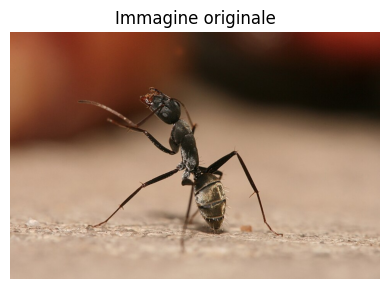

In [2]:
# Installa le librerie se necessario
# !pip install Pillow numpy matplotlib

from PIL import Image, ImageOps, ImageFilter, ImageEnhance
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import colorsys
import os, urllib.request

# ---------- Scarica un'immagine di test ----------
URL = "https://github.com/luigi-asprino/LAB-TDM/blob/main/003/Camponotus_flavomarginatus_ant.jpg?raw=true"
IMG_PATH = "test_image.png"

if not os.path.exists(IMG_PATH):
    urllib.request.urlretrieve(URL, IMG_PATH)

# Converti in RGB (rimuove canale alpha se presente)
img_orig = Image.open(IMG_PATH).convert("RGB")
print(f"Immagine caricata: {img_orig.size[0]}×{img_orig.size[1]} pixel, modalità {img_orig.mode}")
plt.figure(figsize=(4,4))
plt.imshow(img_orig)
plt.axis('off')
plt.title("Immagine originale")
plt.tight_layout()
plt.show()


---
## Sezione 1 – Manipolazione di immagini con Pillow

Le seguenti proprietà fondamentali di un'immagine digitale sono accessibili direttamente
tramite l'oggetto `Image` di Pillow:
- **`image.size`** → tupla `(width, height)`
- **`image.mode`** → stringa che descrive la codifica del colore (es. `'RGB'`, `'L'`, `'RGBA'`)
- **`np.array(image)`** → array NumPy con i valori dei pixel


### Esercizio 1.1 – Proprietà fondamentali di un'immagine

Usando la variabile `img_orig` già caricata nella cella di setup:

1. Stampa larghezza, altezza e modalità colore dell'immagine.
2. Converti l'immagine in un array NumPy e stampa:
   - la forma (`shape`) dell'array,
   - il valore del pixel in posizione (0, 0),
   - il valore del pixel in posizione centrale.
3. Calcola e stampa il numero totale di pixel.


In [ ]:
# Esercizio 1.1 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 1.1
width, height = img_orig.size
print(f"Larghezza : {width} pixel")
print(f"Altezza   : {height} pixel")
print(f"Modalità  : {img_orig.mode}")

arr = np.array(img_orig)
print(f"\nForma array  : {arr.shape}  (H × W × canali)")
print(f"Pixel (0,0)  : R={arr[0,0,0]}  G={arr[0,0,1]}  B={arr[0,0,2]}")
cy, cx = height // 2, width // 2
print(f"Pixel centro : R={arr[cy,cx,0]}  G={arr[cy,cx,1]}  B={arr[cy,cx,2]}")
print(f"\nTotale pixel : {width * height:,}")


### Esercizio 1.2 – Conversione in scala di grigi

Converti `img_orig` in scala di grigi usando `Image.convert('L')`.

1. Visualizza affiancate l'immagine originale e quella in scala di grigi.
2. Confronta i valori medi dei pixel nei due casi usando `np.mean()`.
3. **Riflessione**: perché la media dei pixel RGB non coincide necessariamente con la media dei pixel in scala di grigi?


In [ ]:
# Esercizio 1.2 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 1.2
img_gray = img_orig.convert('L')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_orig)
axes[0].set_title("Originale (RGB)")
axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title("Scala di grigi")
axes[1].axis('off')
plt.tight_layout()
plt.show()

arr_rgb  = np.array(img_orig, dtype=float)
arr_gray = np.array(img_gray, dtype=float)
print(f"Media pixel RGB  (tutti i canali) : {arr_rgb.mean():.2f}")
print(f"Media pixel scala di grigi        : {arr_gray.mean():.2f}")
print()
print("Nota: Pillow usa la formula percettiva  Y = 0.299·R + 0.587·G + 0.114·B")
print("che pesa i canali in modo diverso, quindi la media può differire.")


### Esercizio 1.3 – Ridimensionamento e ritaglio

1. Ridimensiona l'immagine originale a **128 × 128** pixel con `Image.resize()`.
2. Ritaglia la metà superiore dell'immagine originale con `Image.crop()`.
3. Visualizza i tre risultati affiancati con i rispettivi titoli.


In [ ]:
# Esercizio 1.3 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 1.3
img_resized = img_orig.resize((128, 128), Image.LANCZOS)

w, h = img_orig.size
img_cropped = img_orig.crop((0, 0, w, h // 2))   # (left, upper, right, lower)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, titolo in zip(
    axes,
    [img_orig, img_resized, img_cropped],
    [f"Originale {img_orig.size}", f"Ridimensionata {img_resized.size}", f"Ritagliata {img_cropped.size}"]
):
    ax.imshow(im)
    ax.set_title(titolo)
    ax.axis('off')

plt.tight_layout()
plt.show()


### Esercizio 1.4 – Rotazione e specchio

1. Ruota l'immagine di **90°** in senso antiorario.
2. Applica una riflessione orizzontale con `ImageOps.mirror()`.
3. Applica una riflessione verticale con `ImageOps.flip()`.
4. Mostra le quattro immagini (originale + 3 trasformate) in una griglia 2×2.


In [ ]:
# Esercizio 1.4 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 1.4
img_rot90   = img_orig.rotate(90, expand=True)
img_mirror  = ImageOps.mirror(img_orig)
img_flip    = ImageOps.flip(img_orig)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
coppie = [(img_orig,"Originale"), (img_rot90,"Ruotata 90°"),
          (img_mirror,"Specchio (orizzontale)"), (img_flip,"Capovolto (verticale)")]

for ax, (im, titolo) in zip(axes.flat, coppie):
    ax.imshow(im)
    ax.set_title(titolo)
    ax.axis('off')

plt.tight_layout()
plt.show()


### Esercizio 1.5 – Luminosità e contrasto

Usando `ImageEnhance`:

1. Crea versioni dell'immagine con fattori di luminosità **0.5**, **1.0** e **2.0**.
2. Crea versioni con fattori di contrasto **0.5**, **1.0** e **2.0**.
3. Visualizza le 6 immagini in due righe (una per luminosità, una per contrasto) con i rispettivi titoli.


In [ ]:
# Esercizio 1.5 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 1.5
fattori = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, f in enumerate(fattori):
    img_bright  = ImageEnhance.Brightness(img_orig).enhance(f)
    img_contrast = ImageEnhance.Contrast(img_orig).enhance(f)
    axes[0, i].imshow(img_bright)
    axes[0, i].set_title(f"Luminosità × {f}")
    axes[0, i].axis('off')
    axes[1, i].imshow(img_contrast)
    axes[1, i].set_title(f"Contrasto × {f}")
    axes[1, i].axis('off')

plt.suptitle("Effetti di Luminosità e Contrasto", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
## Sezione 2 – Analisi dell'Istogramma e dei Canali Colore

L'**istogramma** di un'immagine mostra la distribuzione dei valori di intensità dei pixel
su tutti i 256 livelli (per immagini a 8 bit per canale).  
Analizzarlo per ciascun canale RGB separatamente rivela la composizione cromatica dell'immagine.


### Esercizio 2.1 – Istogramma dell'immagine in scala di grigi

1. Calcola l'istogramma di `img_gray` con `np.histogram()` (256 bin, range [0, 256]).
2. Visualizzalo come grafico a barre usando `plt.bar()` o `plt.plot()`.
3. Indica con una linea verticale rossa il valore medio dell'intensità.


In [ ]:
# Esercizio 2.1 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 2.1
arr_gray = np.array(img_gray)
hist, bins = np.histogram(arr_gray.flatten(), bins=256, range=(0, 256))
bin_centers = (bins[:-1] + bins[1:]) / 2
media = arr_gray.mean()

plt.figure(figsize=(10, 4))
plt.bar(bin_centers, hist, width=1, color='gray', alpha=0.8, label='Istogramma')
plt.axvline(media, color='red', linewidth=2, linestyle='--', label=f'Media = {media:.1f}')
plt.xlabel("Valore di intensità (0–255)")
plt.ylabel("Numero di pixel")
plt.title("Istogramma – Immagine in scala di grigi")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Valore medio: {media:.2f}   |   Deviazione standard: {arr_gray.std():.2f}")


### Esercizio 2.2 – Istogrammi dei canali RGB

1. Separa i tre canali R, G, B con `Image.split()` (o con NumPy).
2. Calcola e visualizza i tre istogrammi sovrapposti nello stesso grafico,
   usando rispettivamente i colori rosso, verde e blu con `alpha=0.5`.
3. Stampa per ciascun canale: valore minimo, massimo e medio.


In [ ]:
# Esercizio 2.2 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 2.2
r_ch, g_ch, b_ch = img_orig.split()
canali  = [r_ch, g_ch, b_ch]
nomi    = ['Rosso (R)', 'Verde (G)', 'Blu (B)']
colori  = ['red', 'green', 'blue']

plt.figure(figsize=(10, 4))
for ch, nome, col in zip(canali, nomi, colori):
    arr_ch = np.array(ch)
    hist, bins = np.histogram(arr_ch.flatten(), bins=256, range=(0, 256))
    plt.plot((bins[:-1] + bins[1:]) / 2, hist, color=col, alpha=0.7, label=nome)
    print(f"{nome:15s}  min={arr_ch.min():3d}  max={arr_ch.max():3d}  media={arr_ch.mean():.1f}")

plt.xlabel("Valore di intensità (0–255)")
plt.ylabel("Numero di pixel")
plt.title("Istogrammi dei canali RGB sovrapposti")
plt.legend()
plt.tight_layout()
plt.show()


### Esercizio 2.3 – Visualizzazione dei canali come immagini separate

Per ogni canale R, G, B:

1. Crea un'immagine RGB che mostri *solo* quel canale (es. per R: pixel = (R, 0, 0)).
2. Visualizza i tre canali colorati in una griglia 1×3 affiancati all'originale (1×4 in totale).

> **Suggerimento**: Usa `np.zeros_like()` per creare i canali azzerati,
> poi `np.stack()` per ricomporre l'array RGB, e infine `Image.fromarray()`.


In [ ]:
# Esercizio 2.3 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 2.3
arr = np.array(img_orig)
z   = np.zeros_like(arr[:,:,0])  # canale azzerato

img_R = Image.fromarray(np.stack([arr[:,:,0], z, z], axis=2))
img_G = Image.fromarray(np.stack([z, arr[:,:,1], z], axis=2))
img_B = Image.fromarray(np.stack([z, z, arr[:,:,2]], axis=2))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, titolo in zip(axes,
    [img_orig, img_R, img_G, img_B],
    ["Originale", "Solo R", "Solo G", "Solo B"]):
    ax.imshow(im)
    ax.set_title(titolo)
    ax.axis('off')

plt.tight_layout()
plt.show()


### Esercizio 2.4 – Equalizzazione dell'istogramma

L'equalizzazione dell'istogramma migliora il contrasto distribuendo uniformemente
i valori di intensità sull'intero range disponibile.

1. Applica `ImageOps.equalize()` all'immagine in scala di grigi.
2. Visualizza affiancate l'immagine originale e quella equalizzata.
3. Visualizza affiancati i rispettivi istogrammi.
4. Commenta: cosa cambia nella distribuzione dei valori?


In [ ]:
# Esercizio 2.4 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 2.4
img_eq = ImageOps.equalize(img_gray)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].imshow(img_gray, cmap='gray')
axes[0,0].set_title("Scala di grigi – originale")
axes[0,0].axis('off')

axes[0,1].imshow(img_eq, cmap='gray')
axes[0,1].set_title("Scala di grigi – equalizzata")
axes[0,1].axis('off')

for ax, im, titolo, col in zip(
    [axes[1,0], axes[1,1]],
    [img_gray, img_eq],
    ["Istogramma originale", "Istogramma equalizzato"],
    ['gray', 'darkorange']
):
    arr = np.array(im)
    hist, bins = np.histogram(arr.flatten(), bins=256, range=(0,256))
    ax.bar((bins[:-1]+bins[1:])/2, hist, width=1, color=col, alpha=0.8)
    ax.set_xlabel("Intensità")
    ax.set_ylabel("Conteggio")
    ax.set_title(titolo)

plt.tight_layout()
plt.show()
print("Dopo l'equalizzazione l'istogramma risulta più piatto,")
print("indicando un uso più uniforme dell'intero range di intensità.")


---
## Sezione 3 – RGB e HSV: Rappresentazione e Percezione del Colore

Il modello **HSV** (Hue, Saturation, Value) separa le informazioni cromatiche
in tre componenti percettivamente significative:

| Componente | Significato | Range (OpenCV / colorsys) |
|---|---|---|
| **H** (Hue) | Tipo di colore (tonalità) | 0–360° |
| **S** (Saturation) | Purezza del colore | 0–1 |
| **V** (Value) | Luminosità | 0–1 |

Le formule di conversione da RGB (normalizzato 0–1) a HSV sono:

$$M = \max(R,G,B), \quad m = \min(R,G,B), \quad V = M$$

$$S = \begin{cases} 0 & \text{se } V=0 \\ (M-m)/V & \text{altrimenti} \end{cases}$$

$$H = \begin{cases}
60 \cdot (G-B)/(M-m) & \text{se } M=R, G \geq B \\
60 \cdot (G-B)/(M-m) + 360 & \text{se } M=R, G < B \\
60 \cdot (B-R)/(M-m) + 120 & \text{se } M=G \\
60 \cdot (R-G)/(M-m) + 240 & \text{se } M=B
\end{cases}$$


### Esercizio 3.1 – Conversione manuale RGB → HSV

Implementa la conversione RGB→HSV **senza** usare librerie di conversione colore
(senza `colorsys`, senza OpenCV), seguendo le formule delle slide.

1. Definisci la funzione `rgb_to_hsv(r, g, b)` che accetta valori interi 0–255
   e restituisce `(H, S, V)` con H in [0°,360°), S in [0,1], V in [0,1].
2. Verifica la funzione su questi colori di riferimento:
   - Rosso puro: `(255, 0, 0)` → H=0°, S=1, V=1
   - Verde puro: `(0, 255, 0)` → H=120°, S=1, V=1
   - Blu puro:   `(0, 0, 255)` → H=240°, S=1, V=1
   - Bianco:     `(255,255,255)` → H=0°, S=0, V=1
   - Grigio 50%: `(128,128,128)` → S=0, V≈0.5


In [ ]:
# Esercizio 3.1 – Scrivi qui la tua soluzione

def rgb_to_hsv(r, g, b):
    # Normalizza in [0,1]
    # ...
    pass

# Test
colori_test = [
    ((255,   0,   0), "Rosso puro"),
    ((  0, 255,   0), "Verde puro"),
    ((  0,   0, 255), "Blu puro"),
    ((255, 255, 255), "Bianco"),
    ((128, 128, 128), "Grigio 50%"),
]
for (r, g, b), nome in colori_test:
    H, S, V = rgb_to_hsv(r, g, b)
    print(f"{nome:15s}  H={H:6.1f}°  S={S:.3f}  V={V:.3f}")


In [ ]:
# SOLUZIONE 3.1

def rgb_to_hsv(r, g, b):
    """Conversione RGB (0-255) → HSV   H∈[0,360), S,V∈[0,1]"""
    R, G, B = r/255.0, g/255.0, b/255.0
    M = max(R, G, B)
    m = min(R, G, B)
    V = M
    S = 0.0 if V == 0 else (M - m) / V

    if S == 0:
        H = 0.0
    elif M == R:
        H = 60 * (G - B) / (M - m)
        if G < B:
            H += 360
    elif M == G:
        H = 60 * (B - R) / (M - m) + 120
    else:  # M == B
        H = 60 * (R - G) / (M - m) + 240

    return H, S, V


colori_test = [
    ((255,   0,   0), "Rosso puro"),
    ((  0, 255,   0), "Verde puro"),
    ((  0,   0, 255), "Blu puro"),
    ((255, 255, 255), "Bianco"),
    ((128, 128, 128), "Grigio 50%"),
    ((255, 128,   0), "Arancione"),
]
print(f"{'Colore':<15}  {'H':>8}  {'S':>6}  {'V':>6}")
print("-" * 40)
for (r, g, b), nome in colori_test:
    H, S, V = rgb_to_hsv(r, g, b)
    print(f"{nome:<15}  H={H:6.1f}°  S={S:.3f}  V={V:.3f}")


### Esercizio 3.2 – Conversione dell'intera immagine in HSV con Pillow

1. Converti `img_orig` nello spazio HSV usando `img_orig.convert('HSV')`.
2. Estrai i tre canali H, S, V con `split()`.
3. Visualizza i tre canali come immagini in scala di grigi affiancate all'originale.
4. Visualizza i tre istogrammi in un'unica figura con tre subplot.

> **Nota Pillow**: in modalità `HSV`, Pillow usa range interi [0–255] per tutti e tre i canali.
> H=0–255 corrisponde a 0–360°; S e V vanno da 0 a 255.


In [ ]:
# Esercizio 3.2 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 3.2
img_hsv = img_orig.convert('HSV')
H_ch, S_ch, V_ch = img_hsv.split()

# Visualizzazione canali
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, titolo, cmap in zip(
    axes,
    [img_orig, H_ch, S_ch, V_ch],
    ["Originale (RGB)", "Canale H (Tonalità)", "Canale S (Saturazione)", "Canale V (Valore/Luminosità)"],
    [None, 'hsv', 'RdYlGn', 'gray']
):
    ax.imshow(im, cmap=cmap)
    ax.set_title(titolo)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Istogrammi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ch, nome, col in zip(
    axes,
    [H_ch, S_ch, V_ch],
    ["H – Tonalità (0–255 ≡ 0–360°)", "S – Saturazione (0–255)", "V – Valore (0–255)"],
    ['darkorange', 'steelblue', 'dimgray']
):
    arr_ch = np.array(ch)
    hist, bins = np.histogram(arr_ch.flatten(), bins=256, range=(0,256))
    ax.bar((bins[:-1]+bins[1:])/2, hist, width=1, color=col, alpha=0.8)
    ax.set_xlabel("Valore (0–255)")
    ax.set_ylabel("Conteggio")
    ax.set_title(f"Istogramma {nome}")

plt.tight_layout()
plt.show()


### Esercizio 3.3 – Modifica della Saturazione

Una delle applicazioni pratiche dello spazio HSV è la possibilità di modificare
**solo la saturazione** senza alterare la tonalità o la luminosità.

1. Converti `img_orig` in HSV (usa `img_orig.convert('HSV')`).
2. Crea tre varianti modificando *solo* il canale S:
   - **Desaturata**: S moltiplicato per 0 (immagine in toni di grigio cromatico)
   - **Originale**: S invariato
   - **Ipersaturata**: S moltiplicato per 2 (con clip a 255)
3. Riconverti ciascuna variante in RGB con `.convert('RGB')` e visualizza le tre immagini.


In [ ]:
# Esercizio 3.3 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 3.3
arr_hsv = np.array(img_orig.convert('HSV'))
H_arr = arr_hsv[:,:,0]
S_arr = arr_hsv[:,:,1].astype(np.float32)
V_arr = arr_hsv[:,:,2]

risultati = {}
for nome, fattore in [("Desaturata (×0)", 0.0), ("Originale (×1)", 1.0), ("Ipersaturata (×2)", 2.0)]:
    S_new = np.clip(S_arr * fattore, 0, 255).astype(np.uint8)
    arr_new = np.stack([H_arr, S_new, V_arr], axis=2)
    img_new_rgb = Image.fromarray(arr_new, mode='HSV').convert('RGB')
    risultati[nome] = img_new_rgb

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nome, im) in zip(axes, risultati.items()):
    ax.imshow(im)
    ax.set_title(nome)
    ax.axis('off')
plt.suptitle("Effetto della modifica della Saturazione nello spazio HSV", fontsize=13)
plt.tight_layout()
plt.show()


### Esercizio 3.4 – Rotazione della tonalità (Hue Shift)

Un'altra operazione tipica nello spazio HSV è la **rotazione della tonalità**:
aggiungere un offset costante al canale H (con wrap-around modulo 256 in Pillow).

1. Applica rotazioni di **+64** (≈ +90°), **+128** (≈ +180°) e **+192** (≈ +270°) al canale H.
2. Riconverti in RGB e visualizza le 4 immagini (originale + 3 varianti).
3. **Riflessione**: quali colori si trasformano in quali con uno shift di 180°?


In [ ]:
# Esercizio 3.4 – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 3.4
arr_hsv = np.array(img_orig.convert('HSV'))
H_base = arr_hsv[:,:,0].astype(np.int16)
S_arr  = arr_hsv[:,:,1]
V_arr  = arr_hsv[:,:,2]

shifts = [0, 64, 128, 192]
labels = ["Originale (0°)", "+64 ≈ +90°", "+128 ≈ +180°", "+192 ≈ +270°"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, shift, label in zip(axes, shifts, labels):
    H_new = ((H_base + shift) % 256).astype(np.uint8)
    arr_new = np.stack([H_new, S_arr, V_arr], axis=2)
    img_shifted = Image.fromarray(arr_new, mode='HSV').convert('RGB')
    ax.imshow(img_shifted)
    ax.set_title(label)
    ax.axis('off')

plt.suptitle("Rotazione della Tonalità (Hue Shift)", fontsize=13)
plt.tight_layout()
plt.show()

print("Con uno shift di ~180° i colori si spostano verso i loro complementari:")
print("  Rosso  → Ciano")
print("  Verde  → Magenta")
print("  Blu    → Giallo")


### Esercizio 3.5 ★ Sfida – Segmentazione di un colore per Hue

Una delle applicazioni pratiche di HSV è **isolare oggetti per colore**.

1. Converti l'immagine in HSV.
2. Definisci un range di Hue per selezionare un colore dominante (es. rosso/arancione: H ∈ [0, 20] e [200, 256] nel range Pillow 0–255, o verde: H ∈ [40, 90]).
3. Crea una maschera binaria dove i pixel nel range selezionato valgono 255, gli altri 0.
4. Applica la maschera all'immagine originale (pixel fuori dalla maschera → grigio) e visualizza il risultato affiancato all'immagine originale e alla maschera.

> Regola il range di Hue in base ai colori effettivamente presenti nell'immagine di test.


In [ ]:
# Esercizio 3.5 ★ – Scrivi qui la tua soluzione


In [ ]:
# SOLUZIONE 3.5 – segmentazione per Hue (adattata all'immagine di test)

arr_hsv  = np.array(img_orig.convert('HSV'))
H_arr    = arr_hsv[:,:,0]

# Analisi: quali Hue sono più frequenti?
hist_H, bins_H = np.histogram(H_arr.flatten(), bins=256, range=(0,256))
hue_dom = int(np.argmax(hist_H))
print(f"Hue più frequente nell'immagine: {hue_dom}  (≈ {hue_dom/255*360:.0f}°)")

# Definisci un range di ±15 attorno alla Hue dominante
ampiezza = 15
h_low  = (hue_dom - ampiezza) % 256
h_high = (hue_dom + ampiezza) % 256

if h_low <= h_high:
    mask_bool = (H_arr >= h_low) & (H_arr <= h_high)
else:  # wrap-around
    mask_bool = (H_arr >= h_low) | (H_arr <= h_high)

maschera = (mask_bool * 255).astype(np.uint8)

# Applica maschera: fuori maschera → grigio
arr_rgb = np.array(img_orig)
gray_val = 128
arr_result = np.where(mask_bool[:,:,None], arr_rgb,
                      np.full_like(arr_rgb, gray_val))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_orig)
axes[0].set_title("Originale")
axes[0].axis('off')
axes[1].imshow(maschera, cmap='gray')
axes[1].set_title(f"Maschera Hue [{h_low}–{h_high}]\n(Hue dominante ≈ {hue_dom/255*360:.0f}°)")
axes[1].axis('off')
axes[2].imshow(arr_result.astype(np.uint8))
axes[2].set_title("Colore selezionato in evidenza")
axes[2].axis('off')
plt.tight_layout()
plt.show()
